## 1. Imports

The required libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## 2. Loading the Dataset

The customer spending dataset is loaded into a Pandas DataFrame for exploration and analysis.

In [ ]:
data=pd.read_csv(data=pd.read_csv("data/milestone-1-customer-spend.csv"))

## 3. Initial Dataset Inspection

The dataset is inspected to understand its size, structure, column names, data types, and overall contents before preparing the data for machine learning.

In [31]:
data.shape

(20000, 5)

In [32]:
data.head(20)

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,Region,NextMonthSpend
0,6,25.70,7,South,88.51
1,47,85.81,5,East,137.62
2,40,87.63,7,East,148.99
3,27,45.16,4,East,101.25
4,26,67.26,7,East,136.76
5,52,50.06,5,South,92.53
6,6,60.15,3,West,77.69
7,42,34.50,5,West,91.42
8,13,70.04,6,South,120.19
9,6,28.32,8,East,104.81


In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MonthsActive          20000 non-null  int64  
 1   AvgOrderValue         20000 non-null  float64
 2   NumOrdersLastQuarter  20000 non-null  int64  
 3   Region                20000 non-null  str    
 4   NextMonthSpend        20000 non-null  float64
dtypes: float64(2), int64(2), str(1)
memory usage: 781.4 KB


## 4. Data Exploration

The dataset is explored to understand the distribution of the variables and identify any missing or duplicated records before model training.

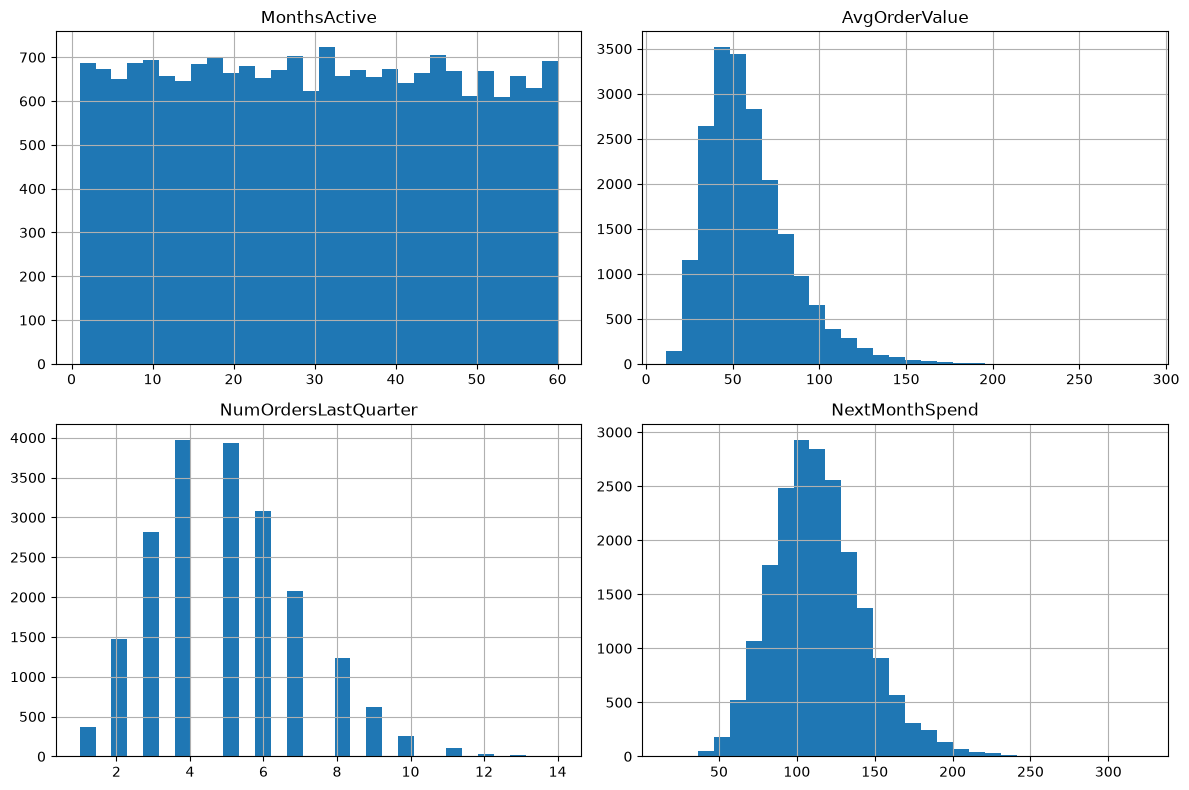

In [34]:
numerical_features=["MonthsActive","AvgOrderValue","NumOrdersLastQuarter","NextMonthSpend"]

data[numerical_features].hist(figsize=(12,8),bins=30)
plt.tight_layout()
plt.show()

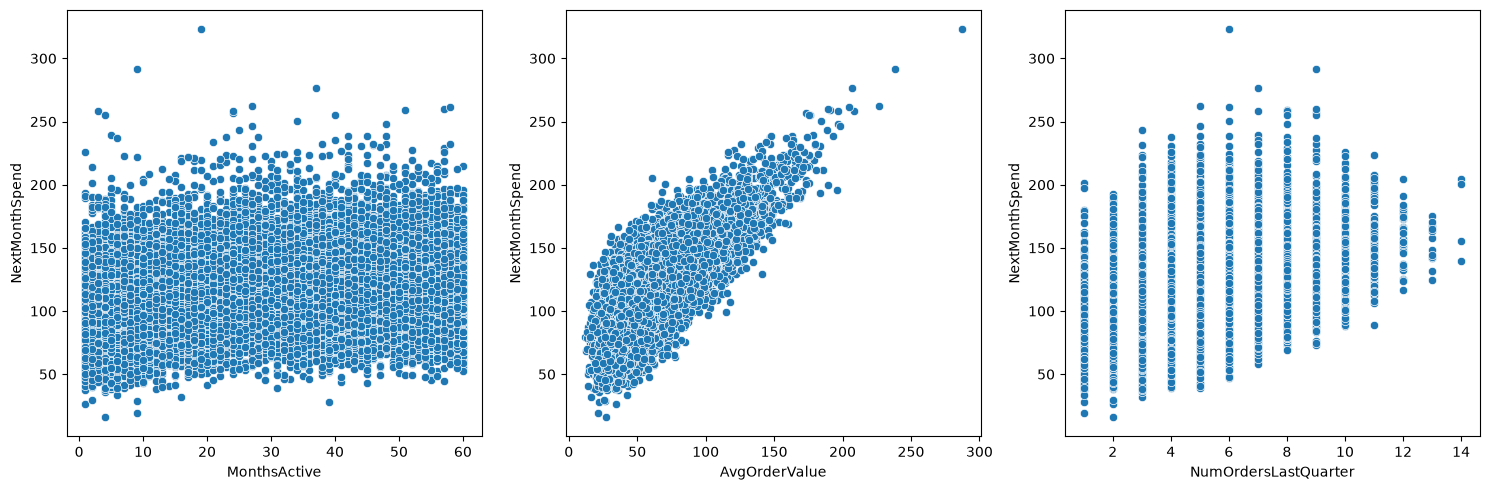

In [35]:
fig,axes=plt.subplots(1,3,figsize=(15,5))

sns.scatterplot(data=data,x="MonthsActive",y="NextMonthSpend",ax=axes[0])
sns.scatterplot(data=data,x="AvgOrderValue",y="NextMonthSpend",ax=axes[1])
sns.scatterplot(data=data,x="NumOrdersLastQuarter",y="NextMonthSpend",ax=axes[2])

plt.tight_layout()
plt.show()

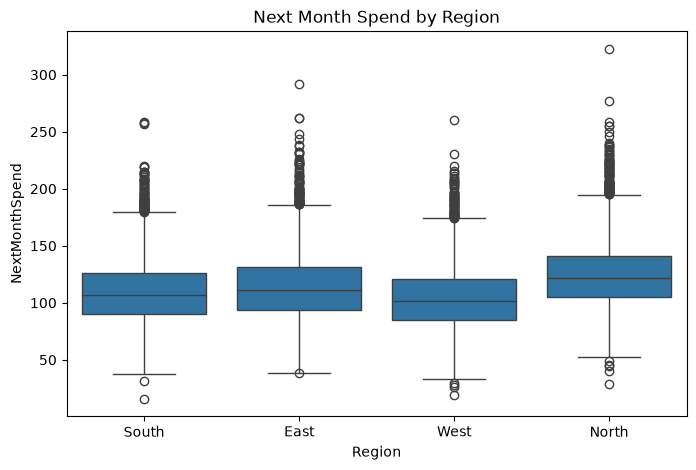

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data,x="Region",y="NextMonthSpend")
plt.title("Next Month Spend by Region")
plt.show()

In [37]:
data.describe()

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,NextMonthSpend
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,30.291200,59.587698,5.009200,114.011969
std,17.288798,24.875161,1.999454,29.594273
min,1.000000,11.530000,1.000000,16.040000
25%,15.000000,41.910000,4.000000,93.630000
50%,30.000000,54.875000,5.000000,111.510000
75%,45.000000,71.920000,6.000000,131.350000
max,60.000000,287.290000,14.000000,322.940000


In [38]:
data["Region"].value_counts()

Region
North    6091
South    4940
East     4917
West     4052
Name: count, dtype: int64

## 5. Data Quality Check

The dataset is checked for missing values and duplicate records to ensure the data is suitable for machine learning.

In [39]:
data.isnull().sum()

MonthsActive            0
AvgOrderValue           0
NumOrdersLastQuarter    0
Region                  0
NextMonthSpend          0
dtype: int64

In [40]:
data.duplicated().sum()

np.int64(0)

## 6. Feature Selection

The available variables are reviewed to identify the features that are relevant for predicting `NextMonthSpend`. The selected features should have a reasonable relationship with the target and be useful for the business problem.

### 6.1 Correlation Analysis

Correlation analysis is used to examine the relationship between the numerical features and `NextMonthSpend`. This helps identify the strength and direction of linear relationships between the variables.

In [41]:
data.corr(numeric_only=True)

,MonthsActive,AvgOrderValue,NumOrdersLastQuarter,NextMonthSpend
MonthsActive,1.000000,0.011131,0.001596,0.167088
AvgOrderValue,0.011131,1.000000,0.001680,0.758631
NumOrdersLastQuarter,0.001596,0.001680,1.000000,0.404895
NextMonthSpend,0.167088,0.758631,0.404895,1.000000


### 6.2 Categorical Feature Review

The `Region` feature is categorical and cannot be assessed using the numerical correlation matrix. It is retained as a predictor because customer spending may vary across different regions.

In [42]:
data["Region"].value_counts()

Region
North    6091
South    4940
East     4917
West     4052
Name: count, dtype: int64

### 6.3 Feature Selection Decision

Based on the correlation analysis and review of the categorical feature, all four available predictors are retained. `AvgOrderValue` has the strongest numerical relationship with `NextMonthSpend`, while `NumOrdersLastQuarter` and `MonthsActive` may provide additional predictive information. `Region` is also retained as a categorical predictor.

## 7. Define Features and Target

The selected predictor variables are separated from the target variable. The predictors will be used by the machine learning models to estimate the customer's `NextMonthSpend`.

In [43]:
X=data.drop("NextMonthSpend",axis=1)
y=data["NextMonthSpend"]

## 8. Train-Test Split

The dataset is first divided into training and testing sets. The test set is kept completely separate and will only be used for final model evaluation. The training portion will later be divided into training and validation sets for model development and comparison.

In [44]:
X_train_val,X_test,y_train_val,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

### 8.1 Train-Validation Split

The training portion is further divided into training and validation sets. The training set is used to fit the models, while the validation set is used during model development to compare and assess model performance before the final evaluation on the unseen test set.

In [45]:
X_train,X_val,y_train,y_val=train_test_split(X_train_val,y_train_val,test_size=0.2,random_state=42)

## 9. Feature Engineering and Preprocessing

The dataset contains both numerical and categorical features. The numerical features are retained in their original form, while the categorical `Region` feature is encoded into numerical values so that it can be used by the machine learning models.

Preprocessing is applied after the train-validation-test split to prevent information from the validation and test sets from influencing model development.

### 9.1 Set Up Preprocessing

The `Region` categorical feature is converted into numerical columns using one-hot encoding. A `ColumnTransformer` is used so that the preprocessing can be applied consistently to the training, validation, and test data.

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features=["Region"]

preprocessor=ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ],
    remainder="passthrough"
)

## 10. Model 1: Linear Regression

Linear Regression is used as the baseline model for predicting `NextMonthSpend`. It assumes that the target can be estimated from a linear combination of the selected features. This provides a simple model that can be compared with a more flexible machine learning approach.

### 10.1 Create the Model Pipeline

The preprocessing step and Linear Regression model are combined into a single pipeline. The pipeline ensures that `Region` is encoded before the model receives the data.

In [47]:
from sklearn.pipeline import Pipeline

linear_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

### 10.2 Train the Model

The Linear Regression pipeline is trained using only the training data. The validation data remains unseen during training and will be used to assess the model's performance.

In [48]:
linear_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['MonthsActive','AvgOrderValue','NumOrdersLastQuarter','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with th

## 11. Model 2: Random Forest Regression

Random Forest Regression is used as a second approach to predict `NextMonthSpend`. Unlike Linear Regression, Random Forest can capture nonlinear relationships and interactions between features. Its performance will be compared with the Linear Regression baseline.

### 11.1 Create the Model Pipeline

The preprocessing step is combined with a Random Forest Regressor in a pipeline so that the same data preparation is applied consistently before model training and prediction.

In [49]:
rf_model=Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("model",RandomForestRegressor(n_estimators=100,random_state=42))
    ]
)

### 11.2 Train the Model

The Random Forest pipeline is trained using the training data. The validation data remains unseen during training and will be used to assess the model's performance.

In [50]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['MonthsActive','AvgOrderValue','NumOrdersLastQuarter','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with th

## 12. Model Evaluation

We have two trained models, so we'll now generate predictions on the validation set and calculate the same regression metrics for both.

### 12.1 Linear Regression Predictions

Predictions are generated for the validation set using the trained Linear Regression model. These predictions will be compared with the actual `NextMonthSpend` values.

In [51]:
linear_val_pred=linear_model.predict(X_val)

### 12.2 Random Forest Predictions

Predictions are generated for the validation set using the trained Random Forest model.

In [52]:
rf_val_pred=rf_model.predict(X_val)

### 12.3 Regression Metrics

The trained models are evaluated on the training, validation, and test sets using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².

Training results show how well each model fits the data it learned from. Validation results are used to compare the models during development, while test results provide the final evaluation on completely unseen data.

In [53]:
linear_train_pred=linear_model.predict(X_train)
linear_val_pred=linear_model.predict(X_val)
linear_test_pred=linear_model.predict(X_test)

rf_train_pred=rf_model.predict(X_train)
rf_val_pred=rf_model.predict(X_val)
rf_test_pred=rf_model.predict(X_test)

In [54]:
results=pd.DataFrame({
    "Model":[
        "Linear Regression","Linear Regression","Linear Regression",
        "Random Forest","Random Forest","Random Forest"
    ],
    "Split":[
        "Train","Validation","Test",
        "Train","Validation","Test"
    ],
    "MAE":[
        mean_absolute_error(y_train,linear_train_pred),
        mean_absolute_error(y_val,linear_val_pred),
        mean_absolute_error(y_test,linear_test_pred),
        mean_absolute_error(y_train,rf_train_pred),
        mean_absolute_error(y_val,rf_val_pred),
        mean_absolute_error(y_test,rf_test_pred)
    ],
    "MSE":[
        mean_squared_error(y_train,linear_train_pred),
        mean_squared_error(y_val,linear_val_pred),
        mean_squared_error(y_test,linear_test_pred),
        mean_squared_error(y_train,rf_train_pred),
        mean_squared_error(y_val,rf_val_pred),
        mean_squared_error(y_test,rf_test_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_train,linear_train_pred)),
        np.sqrt(mean_squared_error(y_val,linear_val_pred)),
        np.sqrt(mean_squared_error(y_test,linear_test_pred)),
        np.sqrt(mean_squared_error(y_train,rf_train_pred)),
        np.sqrt(mean_squared_error(y_val,rf_val_pred)),
        np.sqrt(mean_squared_error(y_test,rf_test_pred))
    ],
    "R²":[
        r2_score(y_train,linear_train_pred),
        r2_score(y_val,linear_val_pred),
        r2_score(y_test,linear_test_pred),
        r2_score(y_train,rf_train_pred),
        r2_score(y_val,rf_val_pred),
        r2_score(y_test,rf_test_pred)
    ]
})

results

,Model,Split,MAE,MSE,RMSE,R²
0,Linear Regression,Train,9.792324,151.280768,12.299625,0.824948
1,Linear Regression,Validation,10.023031,156.438676,12.507545,0.825722
2,Linear Regression,Test,9.846667,152.013303,12.329367,0.830149
3,Random Forest,Train,3.885996,24.185696,4.917895,0.972014
4,Random Forest,Validation,10.561415,176.776200,13.295721,0.803065
5,Random Forest,Test,10.457469,170.623411,13.062290,0.809355


## 13. Model Comparison

The performance of Linear Regression and Random Forest is compared across the training, validation, and test sets. The comparison considers MAE, MSE, RMSE, and R² to determine how accurately and consistently each model predicts `NextMonthSpend`.

### 13.1 Model Performance Comparison

The validation and test results are compared to determine which model provides more reliable predictions on unseen customer data. Training performance is also considered to identify differences between model fit and generalization.

In [55]:
comparison=results.pivot(index="Split",columns="Model",values=["MAE","MSE","RMSE","R²"])

comparison

MAE                             MSE                \
Model      Linear Regression Random Forest Linear Regression Random Forest   
Split                                                                        
Test                9.846667     10.457469        152.013303    170.623411   
Train               9.792324      3.885996        151.280768     24.185696   
Validation         10.023031     10.561415        156.438676    176.776200   

                        RMSE                              R²                
Model      Linear Regression Random Forest Linear Regression Random Forest  
Split                                                                       
Test               12.329367     13.062290          0.830149      0.809355  
Train              12.299625      4.917895          0.824948      0.972014  
Validation         12.507545     13.295721          0.825722      0.803065

## 13.2 Model Comparison Summary

Linear Regression provides more consistent performance across the training, validation, and test sets. Its MAE, MSE, and RMSE remain relatively stable, while its R² remains close to 0.83 across all three splits.

Random Forest achieves substantially stronger performance on the training set, with an R² of 0.972 and an MAE of 3.89. However, its performance decreases considerably on the validation and test sets, where R² falls to 0.803 and 0.809 respectively and MAE increases to 10.56 and 10.46. This difference indicates that the Random Forest model is overfitting the training data.

Based on the validation and test performance, Linear Regression provides the more consistent generalization for predicting `NextMonthSpend`.

## 14. Interpretation of Results

The results show that Linear Regression provides stable predictive performance across all three data splits. Its R² values remain close to 0.83, with 0.825 on the training set, 0.826 on the validation set, and 0.830 on the test set. This indicates that the model explains approximately 83% of the variation in `NextMonthSpend` on unseen data.

The Linear Regression model also produces relatively consistent prediction errors, with test MAE of 9.85 and test RMSE of 12.33. This means that the model's predictions differ from the actual customer spending values by about 9.85 units on average, while the RMSE indicates a typical error magnitude of approximately 12.33 units, with greater penalties for larger errors.

Random Forest achieves a much higher training R² of 0.972 and a lower training MAE of 3.89. However, its performance decreases on unseen data, with a validation R² of 0.803 and a test R² of 0.809. The increase in error from training to validation and test indicates that the model is overfitting the training data and does not generalize as consistently as Linear Regression.

Overall, the results demonstrate that a model with stronger training performance is not necessarily the better model for prediction. For UrbanCart, performance on unseen data and consistency across the data splits are more important when assessing the model's ability to predict future customer spending.

## 15. Business Recommendation

Based on the validation and test results, Linear Regression is recommended as the model for predicting `NextMonthSpend`. It achieved a test R² of 0.830, compared with 0.809 for Random Forest, while also maintaining lower test MAE (9.85 vs 10.46) and lower test RMSE (12.33 vs 13.06).

The model's consistent performance across the training, validation, and test sets suggests that its predictions generalize well to unseen customers. UrbanCart can use the model to estimate expected customer spending and support planning activities such as customer segmentation, sales forecasting, and targeted marketing.

Random Forest should not be selected in its current form because its substantially higher training performance does not translate to better validation or test performance. Its training R² of 0.972 compared with a test R² of 0.809 indicates a significant generalization gap.

The selected Linear Regression model can serve as a baseline for future improvements. UrbanCart could later experiment with additional customer behavior features, alternative regression algorithms, and hyperparameter tuning to determine whether predictive performance can be improved further.